# Test KMRF Training Method on SPY

This notebook tests the enhanced KMRF (KAMA+MSR+RandomForest) regime prediction model using the new features:

1. **Feature Window Expansion** - Use multiple time steps of features to predict regimes
2. **Cross-Asset Input Features** - Use features from multiple asset classes
3. **Custom Random Forest Parameters** - Fine-tune hyperparameters
4. **Master File Loading** - Load data from consolidated master_df.csv and master_label_df.csv

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Import KMRF class
from kmrf import KMRF

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")
print(f"  Pandas version: {pd.__version__}")
print(f"  NumPy version: {np.__version__}")

✓ Libraries imported successfully
  Pandas version: 2.3.3
  NumPy version: 2.3.4


## 2. Initialize KMRF Model

In [2]:
# Initialize KMRF model with new features
model = KMRF(
    asset_class='us_equity',
    asset_name='SPDR S&P 500 ETF',  # Full name as stored in master files
    classification_type='original',
    end_date='20190101',
    use_data_type='master',
    feature_window_size=5,  # Standard single-step features (set >1 for temporal windows)
    feature_asset_classes=['commodity'],  # Cross-asset features
    rf_params={
        'n_estimators': 220,  # Paper Table 2 values
        'max_depth': 13,
        'min_samples_split': 76,
        'min_samples_leaf': 95,
        'max_samples': 0.36,
        'max_features': 0.25,
        'min_weight_fraction_leaf': 0.045,
    }
)

print("\n" + "="*80)
print("KMRF MODEL INITIALIZED")
print("="*80)

KMRF model initialized
  Asset: SPDR S&P 500 ETF
  Asset class: us_equity
  Classification type: original
  End date: 20190101
  Data type: master
  Data path: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_df.csv
  KAMA+MSR model directory: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/saved_models/KAMA_MSR/us_equity/20190101
  Validation period: 2019-02-01 to 2021-12-30
  Test start: 2022-02-01
  Random seed: 1010
  Feature window size: 5 days
  Feature asset classes: ['commodity']
  Custom RF parameters: {'n_estimators': 220, 'max_depth': 13, 'min_samples_split': 76, 'min_samples_leaf': 95, 'max_samples': 0.36, 'max_features': 0.25, 'min_weight_fraction_leaf': 0.045}

KMRF MODEL INITIALIZED


## 3. Load Data from Master Files

Load features and labels using the new master file loading functionality.

In [3]:
# Load feature data from master_df.csv
print("\n" + "="*80)
print("LOADING FEATURE DATA")
print("="*80)
features = model.load_data(use_master_df=True)
print(f"\nFeature data loaded:")
print(f"  Shape: {features.shape}")
print(f"  Date range: {features.index[0]} to {features.index[-1]}")
print(f"  Sample features: {list(features.columns[:5])}")

# Load labels from master_label_df.csv
print("\n" + "="*80)
print("LOADING LABELS")
print("="*80)
labels = model.load_kama_msr_labels(use_master_label_df=True)
print(f"\nLabel data loaded:")
print(f"  Total periods: {len(labels)}")
print(f"  Date range: {labels.index[0]} to {labels.index[-1]}")

# Get features (already loaded in model)
model.get_features()
print(f"\n✓ Model features ready: {model.features.shape}")


LOADING FEATURE DATA

Loading data from: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_df.csv
Loaded data for: SPDR S&P 500 ETF
  Rows: 8242
  Columns: 95
  Date range: 1993-01-29 00:00:00 to 2025-10-24 00:00:00

Feature data loaded:
  Shape: (8242, 95)
  Date range: 1993-01-29 00:00:00 to 2025-10-24 00:00:00
  Sample features: ['open', 'open_lag1d', 'high_lag1d', 'low_lag1d', 'close_lag1d']

LOADING LABELS

LOADING KAMA+MSR LABELS FOR SPDR S&P 500 ETF
Loading from: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_label_df.csv
✓ Loaded labels for: SPDR S&P 500 ETF
  Label date range: 1995-01-30 00:00:00 to 2018-12-31 00:00:00
  Total periods: 6023

  Original 4-regime distribution:
    0 -   LV Bullish:  4560 ( 75.7%)
    1 -   LV Bearish:  1138 ( 18.9%)
    2 -   HV Bullish:    26 (  0.4%)
    3 -   HV Bearish:   299 (  5.0%)

Label data loaded:
  Total periods: 6023
  Date range: 1995-01-30 00:00:00 to 2018-12-31 0

## 4. Load Cross-Asset Features

Load features from multiple asset classes for enhanced prediction.

In [4]:
# Load cross-asset features from master_df.csv
cross_features = model.load_cross_asset_features(use_master_df=True)

print(f"\n✓ Cross-asset features loaded:")
print(f"  Total shape: {cross_features.shape}")
print(f"  Asset classes included: {model.feature_asset_classes}")
print(f"  Unique assets: {cross_features.columns.get_level_values(0).nunique()}")
print(f"  Date range: {cross_features.index[0]} to {cross_features.index[-1]}")


LOADING CROSS-ASSET FEATURES
Target asset: SPDR S&P 500 ETF (us_equity)
Feature asset classes: ['commodity']

  Loading all features from: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_df.csv
    Loaded full shape: (9143, 3559)
    Filtered to ['commodity']: (9143, 966)
    Date range: 1990-01-02 00:00:00 to 2025-10-24 00:00:00

  Combined cross-asset features:
    Total shape: (8242, 966)
    Total assets: 14
    Features per asset: ~69
    Date range: 1993-01-29 00:00:00 to 2025-10-24 00:00:00

✓ Cross-asset features loaded:
  Total shape: (8242, 966)
  Asset classes included: ['commodity']
  Unique assets: 14
  Date range: 1993-01-29 00:00:00 to 2025-10-24 00:00:00


## 5. Prepare Training Data

Prepare the training dataset with cross-asset features using the new `prepare_training_data` method.

In [5]:
# Prepare training data with cross-asset features
# Note: prepare_training_data already prints detailed progress information
X_train, y_train = model.prepare_training_data(
    include_macro=True,
    use_cross_asset_features=True,
    use_master_df=True,
    select_features=False
)

# Training data is now ready - the method above printed all the details
print(f"\n✓ Training data prepared successfully")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_val: {model.X_val.shape}")
print(f"  X_test: {model.X_test.shape}")


PREPARING TRAINING DATA FOR SPDR S&P 500 ETF

Step 1: Loading Target Asset Features
  Target asset features shape: (8242, 95)
  Asset: SPDR S&P 500 ETF

Step 2: Adding Cross-Asset Features
  Feature asset classes: ['commodity']
  Cross-asset features to add: (8242, 966)
  Assets included: 14
  Combined features shape: (8242, 1061)
  = Target (95) + Cross-asset (966)

Step 3: Loading Macroeconomic Data
  Extracted macro data from master_df.csv
  Macro features shape: (9143, 28)
  Combined shape: (8242, 1089)
  = Previous (1061) + Macro (28)

Step 4: Using Original 4-Regime Labels
  (LV Bullish=0, LV Bearish=1, HV Bullish=2, HV Bearish=3)
  Labels Shape: (6023,)

Step 5: Cleaning Features
  Features date range: 1993-01-29 00:00:00 to 2025-10-24 00:00:00
  Labels date range: 1995-01-30 00:00:00 to 2018-12-31 00:00:00
  Note: Keeping all feature dates (including validation/test periods)
  Dropping 1 features with >50% NaN values
  Features cleaned and aligned

Step 6: Expanding Feature Wi

## 6. Train the Model

Train the Random Forest model using the enhanced training method.

In [6]:
# Train the model using fit() method
print("\n" + "="*80)
print("TRAINING KAMA MSR RANDOM FOREST MODEL")
print("="*80)

model.fit()

print("\n✓ Model training complete!")
print(f"  Training samples used: {X_train.shape[0]}")
print(f"  Features used: {X_train.shape[1]}")
print(f"  RF parameters: {model.rf_params}")


TRAINING KAMA MSR RANDOM FOREST MODEL

TRAINING RANDOM FOREST CLASSIFIER
RF Parameters:
  n_estimators: 220
  max_depth: 13
  min_samples_split: 76
  min_samples_leaf: 95
  max_samples: 0.36
  max_features: 0.25
  min_weight_fraction_leaf: 0.045
  random_state: 1010
  n_jobs: -1

Training samples: 5771
Features: 5440
Date range: 1996-01-29 00:00:00 to 2018-12-31 00:00:00

Fitting Random Forest...

TRAINING COMPLETE
Model ready for prediction

✓ Model training complete!
  Training samples used: 5771
  Features used: 5440
  RF parameters: {'n_estimators': 220, 'max_depth': 13, 'min_samples_split': 76, 'min_samples_leaf': 95, 'max_samples': 0.36, 'max_features': 0.25, 'min_weight_fraction_leaf': 0.045}


## 7. Consensus Feature Selection

Use multiple fast feature selection methods to identify the most important features.

This method combines:
1. **RF Feature Importance** - Cumulative importance from the trained model
2. **Variance Threshold** - Removes low-variance features
3. **Mutual Information** - Information-theoretic relevance to target

Features selected by at least 2 out of 3 methods are kept, providing robust feature selection without the computational cost of Boruta (~5-10 minutes vs hours/days).

In [7]:
# Run consensus feature selection using the KMRF class method
selected_features, vote_df, method_results = model.consensus_feature_selection(
    X_train, 
    y_train,
    min_votes=2,  # Features must be selected by at least 2 methods
    variance_threshold=0.01,  # Variance threshold
    cumulative_importance_threshold=0.95,  # RF importance cumulative threshold
    mi_top_pct=0.3  # Top 30% by mutual information
)

print(f"\nTop features with 3 votes:")
print(vote_df[vote_df['votes'] == 3].head(20))


CONSENSUS FEATURE SELECTION
Input features: 5440
Training samples: 5771
Minimum votes required: 2

Method 1: RF Feature Importance (Cumulative 95%)
  Selected: 124 features

Method 2: Variance Threshold (>0.01)
  Selected: 3000 features

Method 3: Mutual Information (Top 30%)
  Selected: 1632 features

Counting votes...

CONSENSUS RESULTS
Selected features: 842 (min_votes >= 2)
Reduction: 84.5%

Vote distribution:
  3 votes:   25 features (  0.5%)
  2 votes:  817 features ( 15.0%)
  1 votes: 3047 features ( 56.0%)
  0 votes: 1551 features ( 28.5%)

Top features (3 votes): 25 features
  (showing first 20)
  ✓ macro_daily_VIX 5d EMA lag1d_lag2
  ✓ log_ret_120d_lag1d_lag1
  ✓ momentum_120d_lag1d_lag4
  ✓ momentum_252d_lag1d_lag1
  ✓ momentum_252d_lag1d_lag4
  ✓ tsfresh_volume_lag1d__mean_lag1
  ✓ macro_daily_VIX 22d EMA lag1d_lag1
  ✓ log_ret_252d_lag1d_lag3
  ✓ macro_daily_VIX 5d EMA lag1d_lag1
  ✓ log_ret_252d_lag1d_lag4
  ✓ log_ret_120d_lag1d_lag4
  ✓ ('Lumber Futures', 'drawdown_lag1

## 8. Retrain with Selected Features & Make Predictions

Retrain the model using only the consensus-selected features, then make predictions on the validation set.

In [8]:
# Retrain model with selected features
print("\n" + "="*80)
print("RETRAINING WITH SELECTED FEATURES")
print("="*80)

X_train_selected = X_train[selected_features]
X_val_selected = model.X_val[selected_features]
X_test_selected = model.X_test[selected_features]

print(f"Original features: {X_train.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")
print(f"Reduction: {100 * (1 - X_train_selected.shape[1]/X_train.shape[1]):.1f}%")

# Update model data splits with selected features
model.X_train = X_train_selected
model.X_val = X_val_selected
model.X_test = X_test_selected

# Retrain the model
print("\nRetraining Random Forest with selected features...")
model.fit()

print("\n✓ Model retrained successfully!")
print(f"  Training samples: {X_train_selected.shape[0]}")
print(f"  Features used: {X_train_selected.shape[1]}")


RETRAINING WITH SELECTED FEATURES
Original features: 5440
Selected features: 842
Reduction: 84.5%

Retraining Random Forest with selected features...

TRAINING RANDOM FOREST CLASSIFIER
RF Parameters:
  n_estimators: 220
  max_depth: 13
  min_samples_split: 76
  min_samples_leaf: 95
  max_samples: 0.36
  max_features: 0.25
  min_weight_fraction_leaf: 0.045
  random_state: 1010
  n_jobs: -1

Training samples: 5771
Features: 842
Date range: 1996-01-29 00:00:00 to 2018-12-31 00:00:00

Fitting Random Forest...

TRAINING COMPLETE
Model ready for prediction

✓ Model retrained successfully!
  Training samples: 5771
  Features used: 842



GENERATING VALIDATION PREDICTIONS

Generating predictions...
  Input shape: (735, 842)
  Using pre-selected features: 842
✓ Generated probability predictions: (735, 4)

Prediction probabilities shape: (735, 4)
Columns: ['P(LV_Bull)', 'P(LV_Bear)', 'P(HV_Bull)', 'P(HV_Bear)']

Sample predictions (first 10 days):
            P(LV_Bull)  P(LV_Bear)  P(HV_Bull)  P(HV_Bear)
date                                                      
2019-02-01    0.066063    0.873863    0.000000    0.060074
2019-02-04    0.101139    0.830185    0.004271    0.064405
2019-02-05    0.121284    0.803560    0.006672    0.068484
2019-02-06    0.175554    0.748370    0.008774    0.067302
2019-02-07    0.319855    0.591702    0.029649    0.058795
2019-02-08    0.440516    0.472907    0.025823    0.060753
2019-02-11    0.396666    0.519462    0.017420    0.066451
2019-02-12    0.363089    0.552458    0.014954    0.069499
2019-02-13    0.333660    0.577321    0.018612    0.070407
2019-02-14    0.405297    0.500257   

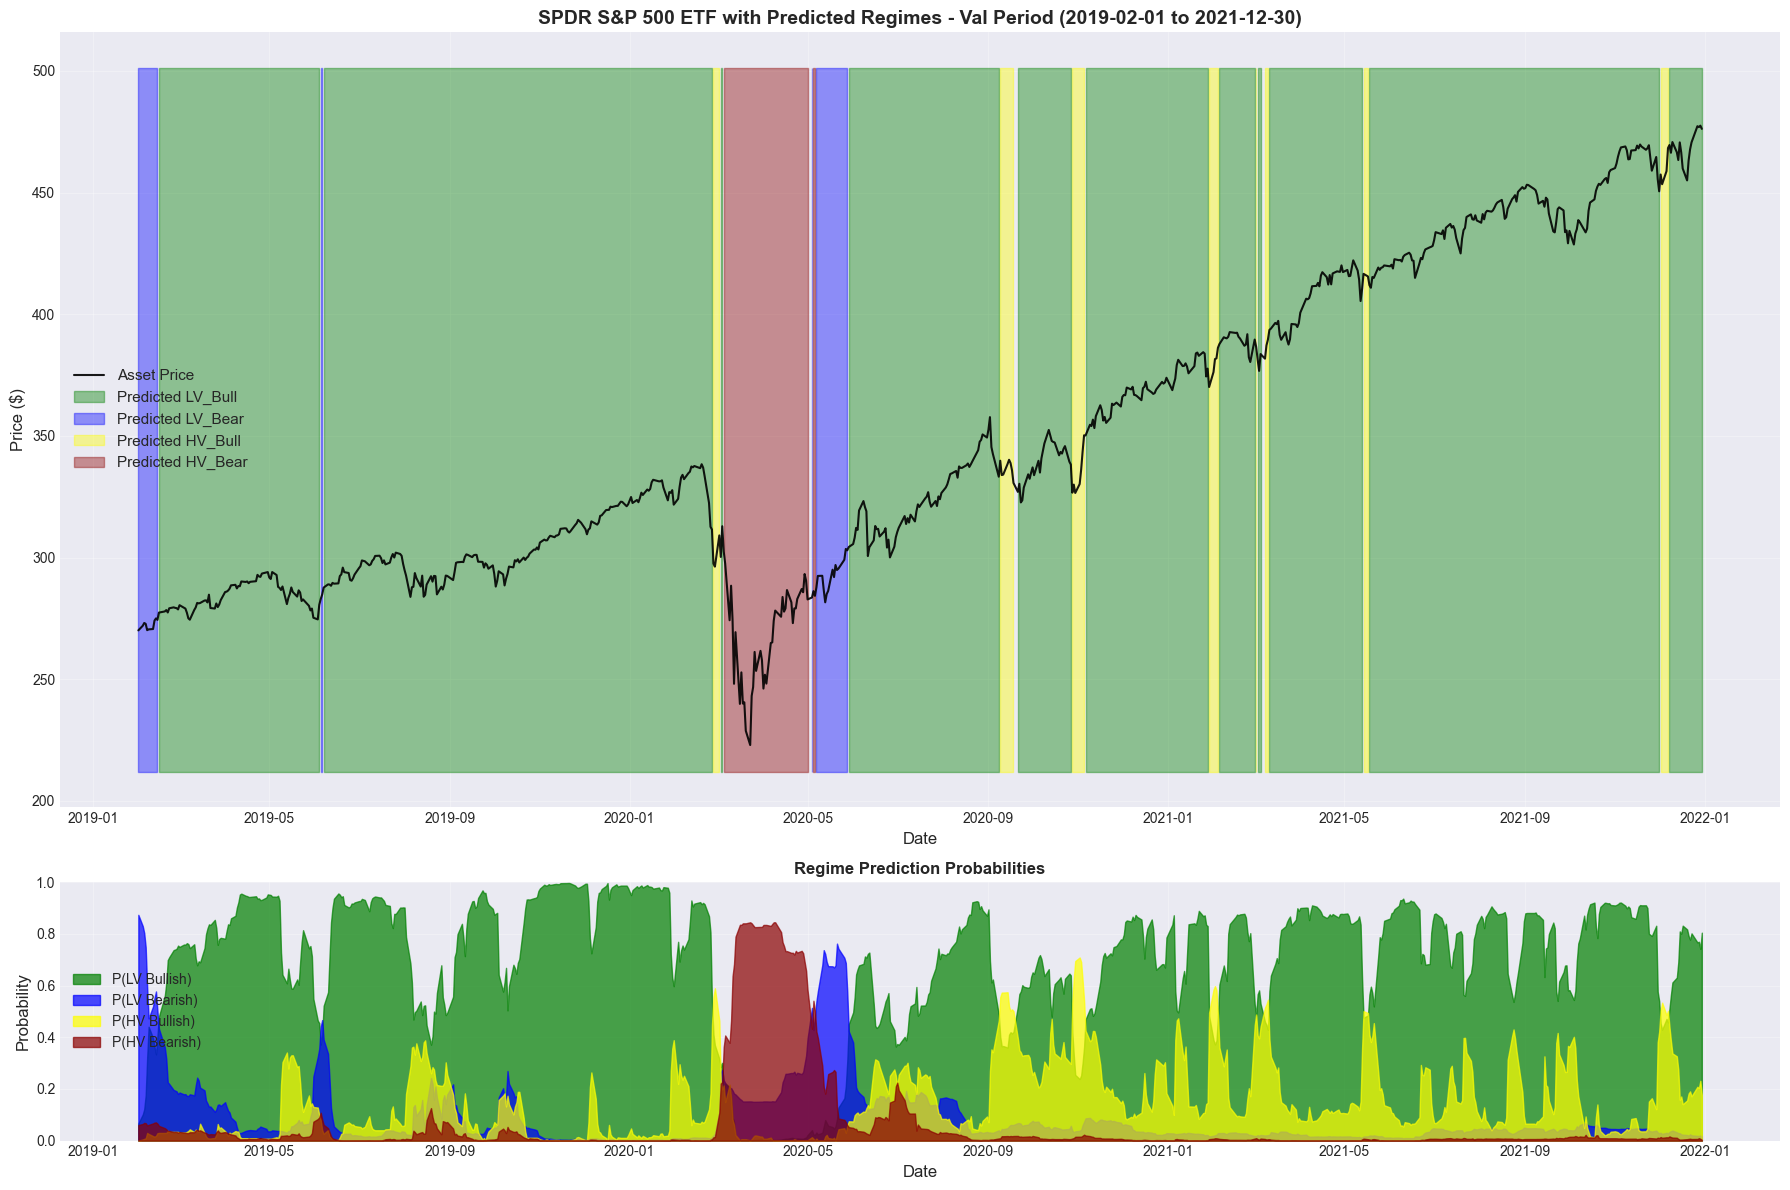

In [9]:
# Make predictions on validation set
print("\n" + "="*80)
print("GENERATING VALIDATION PREDICTIONS")
print("="*80)

y_val_pred_proba = model.predict(test_or_val='val')

print(f"\nPrediction probabilities shape: {y_val_pred_proba.shape}")
print(f"Columns: {list(y_val_pred_proba.columns)}")
print(f"\nSample predictions (first 10 days):")
print(y_val_pred_proba.head(10))

# Visualize predictions
print("\n" + "="*80)
print("VISUALIZING PREDICTIONS")
print("="*80)
model.viz_predictions(test_or_val='val')